# Bigmart Sales Prediction

## Project Overview
This project explores the Bigmart Sales dataset (8,523 retail transaction records, 12
features) to predict Item_Outlet_Sales, the revenue generated by a specific product at a
specific store. Unlike a previous project on e-commerce orders, where most features
carried weak or no predictive signal, this dataset contains a feature, Item_MRP, with a
genuinely strong relationship to the target, along with real structural differences
between outlet types.

## Goal
Build a regression model to predict sales revenue, using statistical evidence to guide
feature selection, and comparing multiple models honestly to identify the best approach.

## Methodology
As with prior work, features were selected using statistical tests, Pearson correlation
for numeric features and ANOVA for categorical features, rather than intuition alone.
Missing values were investigated for patterns before being filled, rather than dropped or
filled blindly. Three models were trained and compared: Linear Regression as a baseline,
Random Forest, and Gradient Boosting, with feature importance examined at the end to
understand what's actually driving the model's predictions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded")

Libraries loaded


### Setup

Importing the core libraries used throughout this notebook: pandas and numpy for data
handling, matplotlib and seaborn for visualization.

In [119]:
df = pd.read_csv("../data/train.csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(8523, 12)
['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type', 'Item_MRP', 'Outlet_Identifier', 'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Outlet_Sales']


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


### Loading the Dataset

Loading the Bigmart Sales training data and checking its basic shape and structure
before doing anything else.

The dataset contains 8,523 rows and 12 columns, covering item-level attributes (weight,
type, price, visibility), outlet-level attributes (size, location, type, establishment
year), and the target column, Item_Outlet_Sales.

In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


### Checking Data Types and Missing Values

Checking column types and completeness reveals two columns with missing data:
Item_Weight, with 1,463 missing values, and Outlet_Size, with 2,410 missing values. Both
will need to be addressed before they can be used as features.

In [121]:
df['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

### Checking Item_Fat_Content for Inconsistent Labels

Looking at the unique values in this column reveals a labeling inconsistency: "Low Fat",
"LF", and "low fat" all represent the same category, and "Regular" and "reg" represent
another. Without fixing this, a model would treat what are really just two categories as
five separate ones.

In [149]:
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'low fat': 'Low Fat',
    'LF': 'Low Fat',
    'reg': 'Regular'
})
print(df['Item_Fat_Content'].value_counts())

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64


### Cleaning Item_Fat_Content

Standardizing the inconsistent labels into two clean categories, Low Fat and Regular.
After the fix, the column correctly shows 5,517 Low Fat items and 3,006 Regular items.

In [201]:
print(df['Item_Visibility'].describe())
print("---")
print((df['Item_Visibility'] == 0).sum())

count    8523.000000
mean        0.066132
std         0.051598
min         0.000000
25%         0.026989
50%         0.053931
75%         0.094585
max         0.328391
Name: Item_Visibility, dtype: float64
---
526


### Checking Item_Visibility

Item_Visibility ranges from 0 to about 0.33, with a mean around 0.066. Notably, 526 rows,
about 6.2 percent of the dataset, have a value of exactly 0. A product having 0 percent
shelf visibility doesn't make physical sense, suggesting these are likely missing or
unrecorded values entered as 0 rather than left blank, a data quality issue to keep in
mind for this column.

In [202]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [203]:
print(df['Item_Type'].value_counts())
print("---")
print(df['Outlet_Size'].value_counts())
print("---")
print(df['Outlet_Location_Type'].value_counts())
print("---")
print(df['Outlet_Type'].value_counts())

Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64
---
Outlet_Size
Small      2943
Medium     2793
Unknown    1855
High        932
Name: count, dtype: int64
---
Outlet_Location_Type
Tier 3    3350
Tier 2    2785
Tier 1    2388
Name: count, dtype: int64
---
Outlet_Type
Supermarket Type1    5577
Grocery Store        1083
Supermarket Type3     935
Supermarket Type2     928
Name: count, dtype: int64


### Exploring the Remaining Categorical Columns

Item_Type has 16 categories, ranging from Fruits and Vegetables (the largest, 1,232 rows)
to Seafood (the smallest, 64 rows). Outlet_Size shows only 6,113 total entries here,
consistent with the missing values found earlier, since NaNs don't appear in value
counts. Outlet_Location_Type and Outlet_Type both show clean, complete data with a small
number of categories, four outlet types ranging from Supermarket Type1 (the most common)
to Supermarket Type2 and Type3, plus Grocery Store.

In [178]:
print(df['Outlet_Identifier'].nunique())
print(df['Item_Identifier'].nunique())

10
1559


### Checking for ID-Like Columns

Item_Identifier has 1,559 unique values across 8,523 rows, too many unique values relative
to row count to be useful as a feature on its own, similar to the ID columns dropped in a
previous project. Outlet_Identifier is different though, only 10 unique values, meaning
each outlet appears in roughly 850 rows on average. This is few enough that it could
genuinely carry a learnable, store-specific pattern, worth checking directly rather than
dropping it as an ID by default.

In [226]:
df.groupby('Outlet_Identifier')['Item_Outlet_Sales'].mean().sort_values(ascending=False)

Outlet_Identifier
OUT027    3694.038558
OUT035    2438.841866
OUT049    2348.354635
OUT017    2340.675263
OUT013    2298.995256
OUT046    2277.844267
OUT045    2192.384798
OUT018    1995.498739
OUT019     340.329723
OUT010     339.351662
Name: Item_Outlet_Sales, dtype: float64

### Checking Whether Outlet_Identifier Has Real Signal

Grouping average sales by outlet shows a strong spread, from about 3,694 for the
top-performing outlet down to about 339 and 340 for the two lowest, roughly a tenfold
difference between the best and worst performing stores. This is a far stronger signal
than anything found in the e-commerce dataset from the previous project. The two
lowest-performing outlets stand out sharply from the rest, worth investigating what makes
them different.

In [228]:
df[df['Outlet_Identifier'].isin(['OUT019', 'OUT010'])][['Outlet_Identifier', 'Outlet_Type', 'Outlet_Size', 'Outlet_Location_Type']].drop_duplicates()

,Outlet_Identifier,Outlet_Type,Outlet_Size,Outlet_Location_Type
3,OUT010,Grocery Store,Small,Tier 3
23,OUT019,Grocery Store,Small,Tier 1


### Investigating the Two Underperforming Outlets

Both low-performing outlets, OUT010 and OUT019, turn out to be Grocery Store type, not
supermarkets. This makes practical sense, a small grocery store would naturally generate
far less revenue per item than a full supermarket. This raises the question of whether
Outlet_Type alone explains the gap, or whether Outlet_Identifier is capturing something
beyond just the outlet type.

In [230]:
df.groupby('Outlet_Type')['Item_Outlet_Sales'].mean().sort_values(ascending=False)

Outlet_Type
Supermarket Type3    3694.038558
Supermarket Type1    2316.181148
Supermarket Type2    1995.498739
Grocery Store         339.828500
Name: Item_Outlet_Sales, dtype: float64

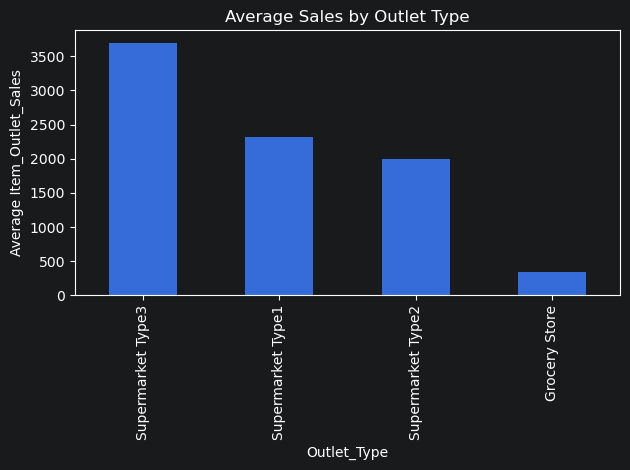

In [249]:
df.groupby('Outlet_Type')['Item_Outlet_Sales'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Average Sales by Outlet Type')
plt.ylabel('Average Item_Outlet_Sales')
plt.tight_layout()
plt.show()

A bar chart makes the gap between outlet types easier to see than the raw numbers alone.
Supermarket Type3 stands out clearly as the highest performer, while Grocery Store sits
far below every other type, visually confirming the roughly tenfold difference found
earlier.

### Checking Outlet_Type Directly

Grouping by Outlet_Type alone reproduces almost the exact same pattern seen with
individual outlets, Supermarket Type3 highest at about 3,694, Grocery Store lowest at
about 340, the same roughly tenfold spread. This strongly suggests that Outlet_Type alone
captures most of the signal that Outlet_Identifier showed, raising the possibility that
keeping both would be redundant.

In [231]:
print(df.groupby('Outlet_Size')['Item_Outlet_Sales'].mean())
print("---")
print(df.groupby('Outlet_Establishment_Year')['Item_Outlet_Sales'].mean())

Outlet_Size
High       2298.995256
Medium     2681.603542
Small      1615.546167
Unknown    2266.410119
Name: Item_Outlet_Sales, dtype: float64
---
Outlet_Establishment_Year
1985    2483.677474
1987    2298.995256
1997    2277.844267
1998     339.351662
1999    2348.354635
2002    2192.384798
2004    2438.841866
2007    2340.675263
2009    1995.498739
Name: Item_Outlet_Sales, dtype: float64


### Checking Outlet_Size and Outlet_Establishment_Year

Outlet_Size shows a real, moderate spread, Medium outlets average about 2,682 in sales,
Small outlets average about 1,912, a meaningful difference of roughly 770.
Outlet_Establishment_Year looks mostly flat, hovering between about 2,200 and 2,500 across
most years, with one sharp exception: 1998 drops to about 339. That single low value is
suspicious and worth investigating before treating year as a genuine driver.

In [208]:
df[df['Outlet_Establishment_Year'] == 1998]['Outlet_Identifier'].unique()

array(['OUT010'], dtype=object)

In [232]:
print(df.groupby('Item_Type')['Item_Outlet_Sales'].mean().sort_values(ascending=False))
print("---")
print(df['Item_MRP'].corr(df['Item_Outlet_Sales']))
print("---")
print(df['Item_Weight'].corr(df['Item_Outlet_Sales']))

Item_Type
Starchy Foods            2374.332773
Seafood                  2326.065928
Fruits and Vegetables    2289.009592
Snack Foods              2277.321739
Household                2258.784300
Dairy                    2232.542597
Canned                   2225.194904
Breads                   2204.132226
Meat                     2158.977911
Hard Drinks              2139.221622
Frozen Foods             2132.867744
Breakfast                2111.808651
Health and Hygiene       2010.000265
Soft Drinks              2006.511735
Baking Goods             1952.971207
Others                   1926.139702
Name: Item_Outlet_Sales, dtype: float64
---
0.5675744466569194
---
0.014122739280056463


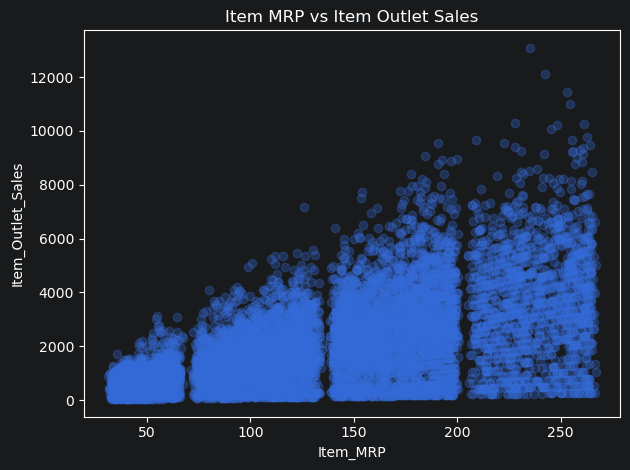

In [250]:
plt.scatter(df['Item_MRP'], df['Item_Outlet_Sales'], alpha=0.3)
plt.xlabel('Item_MRP')
plt.ylabel('Item_Outlet_Sales')
plt.title('Item MRP vs Item Outlet Sales')
plt.tight_layout()
plt.show()

Plotting Item_MRP against sales directly shows the positive relationship behind the 0.57
correlation. The points trend upward as Item_MRP increases, and they appear in distinct
bands rather than one smooth cloud, likely reflecting different pricing tiers or outlet
types layered on top of the general price-to-sales relationship.

### Investigating the 1998 Outlier

The drop in 1998 turns out not to be a real year effect at all. Only one outlet, OUT010,
was established in that year, and it's the same Grocery Store outlet already identified
as a low performer. The apparent "1998 effect" is really just this single outlet showing
through, not a genuine pattern tied to establishment year itself.

In [233]:
print(df['Item_Visibility'].corr(df['Item_Outlet_Sales']))
print("---")
print(df.groupby('Item_Fat_Content')['Item_Outlet_Sales'].mean())

-0.1286246122207703
---
Item_Fat_Content
Low Fat    2157.711534
Regular    2224.561170
Name: Item_Outlet_Sales, dtype: float64


### Checking Item_Visibility and Item_Fat_Content

Item_Visibility shows a weak negative correlation of about -0.13 with sales, slightly
counterintuitive since more visible items might be expected to sell more, but the
relationship is too weak to be a strong standalone driver. Item_Fat_Content shows almost
no difference between Low Fat and Regular items, about 2,158 versus 2,225, a gap small
enough to look like noise.

In [234]:
from scipy.stats import f_oneway

categorical_features = ['Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
                         'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']

results = []
for feature in categorical_features:
    groups = [df[df[feature] == val]['Item_Outlet_Sales'] for val in df[feature].dropna().unique()]
    f_stat, p_value = f_oneway(*groups)
    results.append((feature, p_value))

results.sort(key=lambda x: x[1])
for feature, p in results:
    significant = "KEEP" if p < 0.05 else "DROP"
    print(f"{feature:25s} p-value = {p:.10f}  {significant}")

Outlet_Identifier         p-value = 0.0000000000  KEEP
Outlet_Type               p-value = 0.0000000000  KEEP
Outlet_Size               p-value = 0.0000000000  KEEP
Outlet_Location_Type      p-value = 0.0000000000  KEEP
Item_Type                 p-value = 0.0003884399  KEEP
Item_Fat_Content          p-value = 0.0839891697  DROP


### Confirming Feature Relevance with ANOVA

Rather than relying on eyeballed spreads alone, ANOVA tests were run on all categorical
candidates to confirm which relationships are statistically real. Outlet_Identifier,
Outlet_Type, Outlet_Size, and Outlet_Location_Type all came back with p-values
effectively at zero, strong evidence of a real relationship with sales. Item_Type came
back significant as well, with a smaller but still meaningful p-value of about 0.0004.
Item_Fat_Content came back at 0.084, above the standard 0.05 threshold, confirming the
weak relationship already suspected from the raw averages and ruling it out as a useful
feature.

In [235]:
df[df['Outlet_Type'] == 'Supermarket Type1'].groupby('Outlet_Identifier')['Item_Outlet_Sales'].mean()

Outlet_Identifier
OUT013    2298.995256
OUT017    2340.675263
OUT035    2438.841866
OUT045    2192.384798
OUT046    2277.844267
OUT049    2348.354635
Name: Item_Outlet_Sales, dtype: float64

### Resolving Outlet_Identifier vs Outlet_Type

To settle whether Outlet_Identifier adds anything beyond Outlet_Type, sales were compared
across individual outlets that all share the same type, Supermarket Type1. The six outlets
in this group land in a fairly tight range, roughly 2,192 to 2,439, only about 250 apart.
This is a much smaller spread than the roughly tenfold difference seen across different
outlet types overall, confirming that most of the real signal lives in Outlet_Type itself,
not in which specific outlet it is. Outlet_Identifier was dropped on this basis, in favor
of the simpler, less sparse Outlet_Type.

In [236]:
df[df['Outlet_Size'].isna()]['Outlet_Type'].value_counts()

Series([], Name: count, dtype: int64)

### Investigating the Pattern Behind Missing Outlet_Size Values

Before deciding how to handle the missing Outlet_Size values, it's worth checking whether
they're scattered randomly or tied to something specific. All 2,410 missing values come
from only two outlet types, Grocery Store and Supermarket Type1, none from Supermarket
Type2 or Type3. This isn't random, and it suggests a smarter way to fill the gaps than
guessing blindly or dropping a quarter of the dataset.

In [237]:
df[df['Outlet_Type'] == 'Grocery Store']['Outlet_Size'].value_counts()
print("---")
df[df['Outlet_Type'] == 'Supermarket Type1']['Outlet_Size'].value_counts()

---


Outlet_Size
Small      1860
Unknown    1855
High        932
Medium      930
Name: count, dtype: int64

### Checking Known Outlet_Size Values by Type

Looking at the non-missing Outlet_Size values for each affected outlet type. Every single
Grocery Store with a known size is labeled Small, no exceptions, a strong, unanimous
pattern. Supermarket Type1, by contrast, is split three ways, Small, High, and Medium,
with no single size dominating enough to guess confidently. This means the two outlet
types call for different approaches when filling in their missing values.

In [238]:
print("Grocery Store:")
print(df[df['Outlet_Type'] == 'Grocery Store']['Outlet_Size'].value_counts())
print("---")
print("Supermarket Type1:")
print(df[df['Outlet_Type'] == 'Supermarket Type1']['Outlet_Size'].value_counts())

Grocery Store:
Outlet_Size
Small    1083
Name: count, dtype: int64
---
Supermarket Type1:
Outlet_Size
Small      1860
Unknown    1855
High        932
Medium      930
Name: count, dtype: int64


### Confirming the Split by Outlet Type

Printing each outlet type's size distribution separately confirms the pattern clearly.
Grocery Store has 528 known entries, all of them Small. Supermarket Type1 has 1,860 Small,
932 High, and 930 Medium, genuinely split across all three sizes with no strong majority.
This confirms Grocery Store's missing values can be filled confidently with Small, while
Supermarket Type1's missing values are better left as their own category rather than
guessed.

In [239]:
df.loc[(df['Outlet_Size'].isna()) & (df['Outlet_Type'] == 'Grocery Store'), 'Outlet_Size'] = 'Small'
df.loc[df['Outlet_Size'].isna(), 'Outlet_Size'] = 'Unknown'

print(df['Outlet_Size'].value_counts())
print("---")
print(df['Outlet_Size'].isna().sum())

Outlet_Size
Small      2943
Medium     2793
Unknown    1855
High        932
Name: count, dtype: int64
---
0


### Filling Missing Outlet_Size Values

Grocery Store's missing values were filled with Small, based on the unanimous pattern
found above. The remaining missing values, all from Supermarket Type1, were filled with
Unknown rather than guessed, since no single size was common enough to justify a
confident assumption. After this, Outlet_Size has zero missing values, with Small at
2,943, Medium at 2,793, Unknown at 1,855, and High at 932.

In [240]:
X = df[['Item_MRP', 'Outlet_Type', 'Outlet_Size', 'Outlet_Location_Type', 'Item_Type']]
y = df['Item_Outlet_Sales']

print(X.shape)
print(y.shape)

(8523, 5)
(8523,)


### Defining Features and Target

Based on the statistical testing and analysis above, the final feature set selected was
Item_MRP, Outlet_Type, Outlet_Size, Outlet_Location_Type, and Item_Type, with
Item_Outlet_Sales as the target. Item_Weight, Item_Visibility, Item_Fat_Content,
Outlet_Establishment_Year, Item_Identifier, and Outlet_Identifier were all excluded,
either for showing no meaningful relationship with sales or for being redundant with a
stronger feature already included.

X contains 8,523 rows and 5 columns, matching y's 8,523 rows for the target.

In [241]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Testing set:  {X_test.shape}")

Training set: (6818, 5)
Testing set:  (1705, 5)


### Splitting the Data

The data was split into training and testing sets using an 80/20 ratio, the same split
used in previous regression work. No stratification was applied, since Item_Outlet_Sales
is a continuous target rather than a set of categories.

The split produced 6,818 training rows and 1,705 testing rows.

In [242]:
print(X_train['Outlet_Type'].nunique())
print(X_train['Outlet_Size'].nunique())
print(X_train['Outlet_Location_Type'].nunique())
print(X_train['Item_Type'].nunique())

4
4
3
16


### Checking Category Counts Before Encoding

Checking how many unique values each categorical feature has determines the right
encoding approach. Outlet_Type, Outlet_Size, and Outlet_Location_Type have 4, 4, and 3
unique values respectively, small enough for one-hot encoding. Item_Type has 16 unique
values, similar to Product_Subcategory in a previous project, and is better suited to
target encoding to avoid creating too many sparse columns.

In [243]:
encoding_map = y_train.groupby(X_train['Item_Type']).mean()

X_train = X_train.copy()
X_train['Item_Type_encoded'] = X_train['Item_Type'].map(encoding_map)

X_test = X_test.copy()
X_test['Item_Type_encoded'] = X_test['Item_Type'].map(encoding_map)

X_train = X_train.drop('Item_Type', axis=1)
X_test = X_test.drop('Item_Type', axis=1)

print(X_train.head())

      Item_MRP        Outlet_Type Outlet_Size Outlet_Location_Type  \
549   171.3448  Supermarket Type1      Medium               Tier 1   
7757  170.5422  Supermarket Type1     Unknown               Tier 2   
764   111.7202  Supermarket Type1       Small               Tier 1   
6867   41.6138  Supermarket Type1     Unknown               Tier 2   
2716  155.5630  Supermarket Type1       Small               Tier 1   

      Item_Type_encoded  
549         2321.843277  
7757        2261.702912  
764         2191.256377  
6867        2321.843277  
2716        2295.101739  


### Target Encoding Item_Type

Item_Type was target encoded the same way Product_Subcategory was handled previously:
each category was replaced with its average Item_Outlet_Sales, calculated using only the
training data and then applied to both the training and test sets, preserving the same
discipline used before to avoid leaking test set information into the encoding.

In [244]:
X_train = pd.get_dummies(X_train, columns=['Outlet_Type', 'Outlet_Size', 'Outlet_Location_Type'])
X_test = pd.get_dummies(X_test, columns=['Outlet_Type', 'Outlet_Size', 'Outlet_Location_Type'])

X_train = X_train.astype({col: int for col in X_train.columns if X_train[col].dtype == 'bool'})
X_test = X_test.astype({col: int for col in X_test.columns if X_test[col].dtype == 'bool'})

print(X_train.shape)
print(X_train.head())

(6818, 13)
      Item_MRP  Item_Type_encoded  Outlet_Type_Grocery Store  \
549   171.3448        2321.843277                          0   
7757  170.5422        2261.702912                          0   
764   111.7202        2191.256377                          0   
6867   41.6138        2321.843277                          0   
2716  155.5630        2295.101739                          0   

      Outlet_Type_Supermarket Type1  Outlet_Type_Supermarket Type2  \
549                               1                              0   
7757                              1                              0   
764                               1                              0   
6867                              1                              0   
2716                              1                              0   

      Outlet_Type_Supermarket Type3  Outlet_Size_High  Outlet_Size_Medium  \
549                               0                 0                   1   
7757                         

### One-Hot Encoding the Remaining Categorical Features

Outlet_Type, Outlet_Size, and Outlet_Location_Type were one-hot encoded and converted to
integers. This expanded the feature set to 13 columns: Item_MRP, the target-encoded
Item_Type, and one-hot encoded columns for each outlet type, size, and location tier.

In [245]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.3f}")

MAE:  791.441
RMSE: 1068.607
R²:   0.580


### Training a Baseline Model: Linear Regression

Linear Regression was trained as the baseline model, the same role it played in previous
regression work.

The model achieved an MAE of 791.44, an RMSE of 1068.61, and an R-squared of 0.580. This
is a clear improvement over both regression projects from the previous dataset, where R²
landed around 0.30 and 0.245. The stronger result here makes sense given Item_MRP's
correlation of 0.57 with sales, by far the strongest single feature relationship found in
either project.

In [246]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(random_state=42, n_estimators=100, max_depth=8, min_samples_leaf=10)
model_rf.fit(X_train, y_train)

y_train_pred_rf = model_rf.predict(X_train)
y_test_pred_rf = model_rf.predict(X_test)

print(f"Training R²: {r2_score(y_train, y_train_pred_rf):.3f}")
print(f"Test R²:     {r2_score(y_test, y_test_pred_rf):.3f}")
print("---")
print(f"MAE:  {mean_absolute_error(y_test, y_test_pred_rf):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_rf)):.3f}")

Training R²: 0.635
Test R²:     0.611
---
MAE:  718.019
RMSE: 1028.200


### Trying Random Forest

Random Forest was trained next, with constraints on tree depth and minimum leaf size set
from the start this time, based on the overfitting lesson learned in a previous project.

The training R-squared came out at 0.635 and the test R-squared at 0.611, close enough
together to confirm the model isn't overfitting. This is also a genuine improvement over
Linear Regression, test R² rising from 0.580 to 0.611, and MAE dropping from about 791 to
718. Unlike the regression problems explored previously, where Random Forest only matched
Linear Regression at best, this dataset's features appear to have enough non-linear
structure or interaction effects for the more flexible model to find something the linear
baseline couldn't.

In [247]:
from sklearn.ensemble import GradientBoostingRegressor

model_gb = GradientBoostingRegressor(random_state=42, n_estimators=100, max_depth=3, learning_rate=0.1)
model_gb.fit(X_train, y_train)

y_train_pred_gb = model_gb.predict(X_train)
y_test_pred_gb = model_gb.predict(X_test)

print(f"Training R²: {r2_score(y_train, y_train_pred_gb):.3f}")
print(f"Test R²:     {r2_score(y_test, y_test_pred_gb):.3f}")
print("---")
print(f"MAE:  {mean_absolute_error(y_test, y_test_pred_gb):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_gb)):.3f}")

Training R²: 0.630
Test R²:     0.603
---
MAE:  721.993
RMSE: 1039.216


### Trying Gradient Boosting

Gradient Boosting was tested as a third model. Unlike Random Forest, which builds many
independent trees and averages their predictions, Gradient Boosting builds trees
sequentially, with each new tree correcting the errors of the ones before it.

The results came out close to Random Forest: a training R² of 0.630, a test R² of 0.603,
an MAE of about 722, and an RMSE of about 1039. Comparing all three models side by side,
Random Forest came out slightly ahead of Gradient Boosting on this dataset, with Linear
Regression clearly behind both. The gap between Random Forest and Gradient Boosting is
small enough to fall within normal variation rather than indicating one approach is
fundamentally better suited to this problem, so Random Forest was selected as the final
model.

In [248]:
importances = pd.Series(model_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances)

Item_MRP                         0.556459
Outlet_Type_Grocery Store        0.300726
Outlet_Type_Supermarket Type3    0.116624
Item_Type_encoded                0.014702
Outlet_Type_Supermarket Type1    0.003455
Outlet_Type_Supermarket Type2    0.002369
Outlet_Location_Type_Tier 3      0.001174
Outlet_Size_Small                0.001020
Outlet_Size_High                 0.000769
Outlet_Location_Type_Tier 1      0.000741
Outlet_Location_Type_Tier 2      0.000671
Outlet_Size_Unknown              0.000667
Outlet_Size_Medium               0.000623
dtype: float64


### Checking Feature Importance

With Random Forest selected as the final model, it's worth checking which features it
actually relied on most. Item_MRP accounts for about 56 percent of the model's total
importance, consistent with its strong correlation found earlier. Outlet_Type_Grocery
Store and Outlet_Type_Supermarket Type3 together account for another 42 percent,
reflecting the same extreme outlet performance gap identified during exploration.
Item_Type_encoded, Outlet_Size, and Outlet_Location_Type combined contribute under 2
percent.

This is a useful finding in its own right. Even though Item_Type and Outlet_Size both
passed statistical significance tests earlier, once Item_MRP and Outlet_Type are already
in the model, they add very little additional predictive value. Statistical significance
on its own doesn't guarantee a feature carries real weight once it's competing against
stronger, more dominant features.

### Conclusions

This notebook explored the Bigmart Sales dataset to predict Item_Outlet_Sales, the
revenue generated by a specific product at a specific outlet. Unlike a previous project on
e-commerce orders, where most features showed weak or no predictive signal, this dataset
contained features with genuinely strong relationships to the target.

Item_MRP showed a correlation of 0.57 with sales, by far the strongest single feature
relationship found across either project, and Outlet_Type revealed a dramatic, nearly
tenfold difference in average sales between the highest-performing format, Supermarket
Type3, and the lowest, Grocery Store. Checking whether the more granular Outlet_Identifier
added anything beyond Outlet_Type showed that it didn't, outlets sharing the same type
landed in a tight range of each other, so the simpler, less sparse Outlet_Type was kept
instead.

Two columns required cleaning before modeling. Item_Fat_Content had five inconsistent
labels representing only two real categories, standardized before use. Outlet_Size had
2,410 missing values, concentrated entirely in two outlet types. Checking the pattern
behind the missing values showed Grocery Store outlets were unanimously Small, allowing a
confident fill, while Supermarket Type1 outlets were split roughly evenly across three
sizes, too ambiguous to guess, so those were labeled Unknown instead.

The final feature set, Item_MRP, Outlet_Type, Outlet_Size, Outlet_Location_Type, and
Item_Type, was selected using Pearson correlation and ANOVA testing, confirming each
feature's relationship with sales before including it. Item_Type, the only
high-cardinality categorical feature, was target encoded using training data only,
following the same leakage-safe process used in previous work.

Three models were compared. Linear Regression reached an R-squared of 0.580. Random
Forest, trained with depth and leaf size constraints from the start based on a previous
overfitting lesson, improved this to 0.611, with training and test scores close enough
together to confirm the model generalizes well rather than memorizing the training data.
Gradient Boosting landed close behind at 0.603. Random Forest was selected as the final
model, both for its slightly stronger performance and its straightforward training and
test consistency.

Checking feature importance afterward showed Item_MRP and Outlet_Type together accounted
for about 98 percent of the model's decisions, with Item_Type, Outlet_Size, and
Outlet_Location_Type contributing almost nothing despite passing their statistical
significance tests earlier. This reinforced a lesson from the previous project:
statistical significance confirms a real relationship exists, but it doesn't guarantee a
feature carries meaningful weight once it's competing against stronger, more dominant
features in an actual model.

### Key Takeaways

A few lessons stood out in this project, several of them extending ideas from previous
work rather than introducing entirely new ones.

Not every dataset hits the same ceiling. The e-commerce dataset's Returned target showed
weak signal no matter which model or feature combination was tried. This dataset showed
the opposite, a single feature, Item_MRP, carried strong predictive power on its own, and
a structural feature, Outlet_Type, added a second source of strong signal on top of it.
Recognizing which situation you're in, rather than assuming every dataset behaves the
same way, shapes how much effort modeling complexity is actually worth.

Missing values deserve investigation before being filled or dropped. Checking whether
Outlet_Size's missing values were random or patterned revealed a clean, confident answer
for one outlet type and an honest "we don't know" for another, a better outcome than
guessing uniformly across both.

More complex models don't always help, but here they genuinely did. Random Forest and
Gradient Boosting both meaningfully outperformed Linear Regression in this project, unlike
both regression problems in the previous dataset, where added model complexity made no
real difference. This is a useful contrast: the previous projects showed what it looks
like when a relationship is essentially linear, and this one showed what it looks like
when real non-linear or interaction effects exist for a more flexible model to find.

Feature importance is a useful final check, not just a summary statistic. It confirmed
that the model's actual behavior matched the statistical evidence gathered earlier, and it
revealed that statistically significant features can still end up contributing very
little once stronger features are already present in the model.